In [63]:
# ══ CELL 1: Install ══
!pip install streamlit plotly scikit-learn scipy pyngrok seaborn -q
print("All packages installed!")


All packages installed!


In [64]:

# ══ CELL 2: Imports ══
import pandas as pd, numpy as np, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import dendrogram, linkage
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
COLORS = {'High-Performing':'#10b981','Moderate':'#f59e0b','At-Risk':'#ef4444'}
N_CLUSTERS = 3
print("Imports done!")


Imports done!


In [65]:

# ══ CELL 3: Upload CSV ══
from google.colab import files
import io
print("Upload Mtech_Selected_ML_Ready.csv ...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"Loaded: {df_raw.shape[0]} students x {df_raw.shape[1]} columns")
display(df_raw.head())
display(df_raw.describe().round(2))
print("Missing values:", df_raw.isnull().sum().sum())


Upload Mtech_Selected_ML_Ready.csv ...


Saving Mtechlabeldataset.csv to Mtechlabeldataset (2).csv
Loaded: 57 students x 20 columns


,Roll Number,Gender,10th Score(%),12th Score(%),CGPA(%),QUIZ 1,QUIZ 2,QUIZ 3,QUIZ 4,QUIZ 5,QUIZ 6,AVG,QUIZ Attempt,Attendance,Aim/Objective,Prior Knowledge of subject,Resource Visited,No. of Replies Posted,No. of views on forum,Class
0,101,1,90.0,92.0,89.58,83.333333,100.000000,100.00,0,80,75.76,73.182222,5,6,3,5,5,0,6,c1
1,102,1,87.0,91.0,87.56,91.666667,100.000000,76.67,70,0,87.88,71.036111,5,9,2,2,1,0,3,c1
2,103,1,93.0,85.0,81.22,83.333333,66.666667,0.00,0,0,83.33,38.888333,3,3,3,4,4,0,0,c2
3,104,1,93.8,94.2,85.04,91.666667,91.666667,80.00,80,70,0.00,68.888889,5,5,2,3,4,1,16,c1
4,106,1,96.2,92.4,79.50,79.166667,91.666667,90.00,0,80,81.82,70.442222,5,0,3,2,2,0,3,c1


,Roll Number,Gender,10th Score(%),12th Score(%),CGPA(%),QUIZ 1,QUIZ 2,QUIZ 3,QUIZ 4,QUIZ 5,QUIZ 6,AVG,QUIZ Attempt,Attendance,Aim/Objective,Prior Knowledge of subject,Resource Visited,No. of Replies Posted,No. of views on forum
count,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00,57.00
mean,131.58,0.53,87.88,84.41,78.03,83.12,85.09,59.36,67.54,63.86,64.59,70.59,5.44,4.21,2.12,3.04,3.53,0.51,13.16
std,17.98,0.50,7.75,8.41,11.19,10.10,15.98,36.92,33.93,27.82,25.79,16.72,0.98,2.86,0.76,0.98,0.83,0.57,12.14
min,101.00,0.00,58.00,60.00,9.11,58.33,33.33,0.00,0.00,0.00,0.00,25.00,2.00,0.00,1.00,1.00,1.00,0.00,0.00
25%,117.00,0.00,85.86,79.00,75.00,79.17,83.33,26.67,60.00,60.00,63.13,66.34,5.00,2.00,2.00,2.00,3.00,0.00,3.00
50%,131.00,1.00,90.00,87.00,79.46,83.33,91.67,70.00,80.00,70.00,74.24,73.71,6.00,4.00,2.00,3.00,4.00,0.00,10.00
75%,147.00,1.00,93.00,90.06,82.94,91.67,100.00,93.33,90.00,80.00,80.30,81.52,6.00,6.00,3.00,4.00,4.00,1.00,20.00
max,166.00,1.00,96.60,95.20,93.10,100.00,100.00,100.00,100.00,90.00,90.91,94.67,6.00,11.00,3.00,5.00,5.00,2.00,39.00


Missing values: 0


✅ Renamed 'Roll Number' -> 'Student ID'
✅ ID column: Student ID
✅ Features selected (11): ['10th Score(%)', '12th Score(%)', 'CGPA(%)', 'AVG', 'QUIZ Attempt', 'Attendance', 'Aim/Objective', 'Prior Knowledge of subject', 'Resource Visited', 'No. of Replies Posted', 'No. of views on forum']

✅ PCA variance explained: 46.2%
   PC1: 25.5%  |  PC2: 20.6%
✅ Scaled shape: (57, 11)
✅ Preprocessing complete!


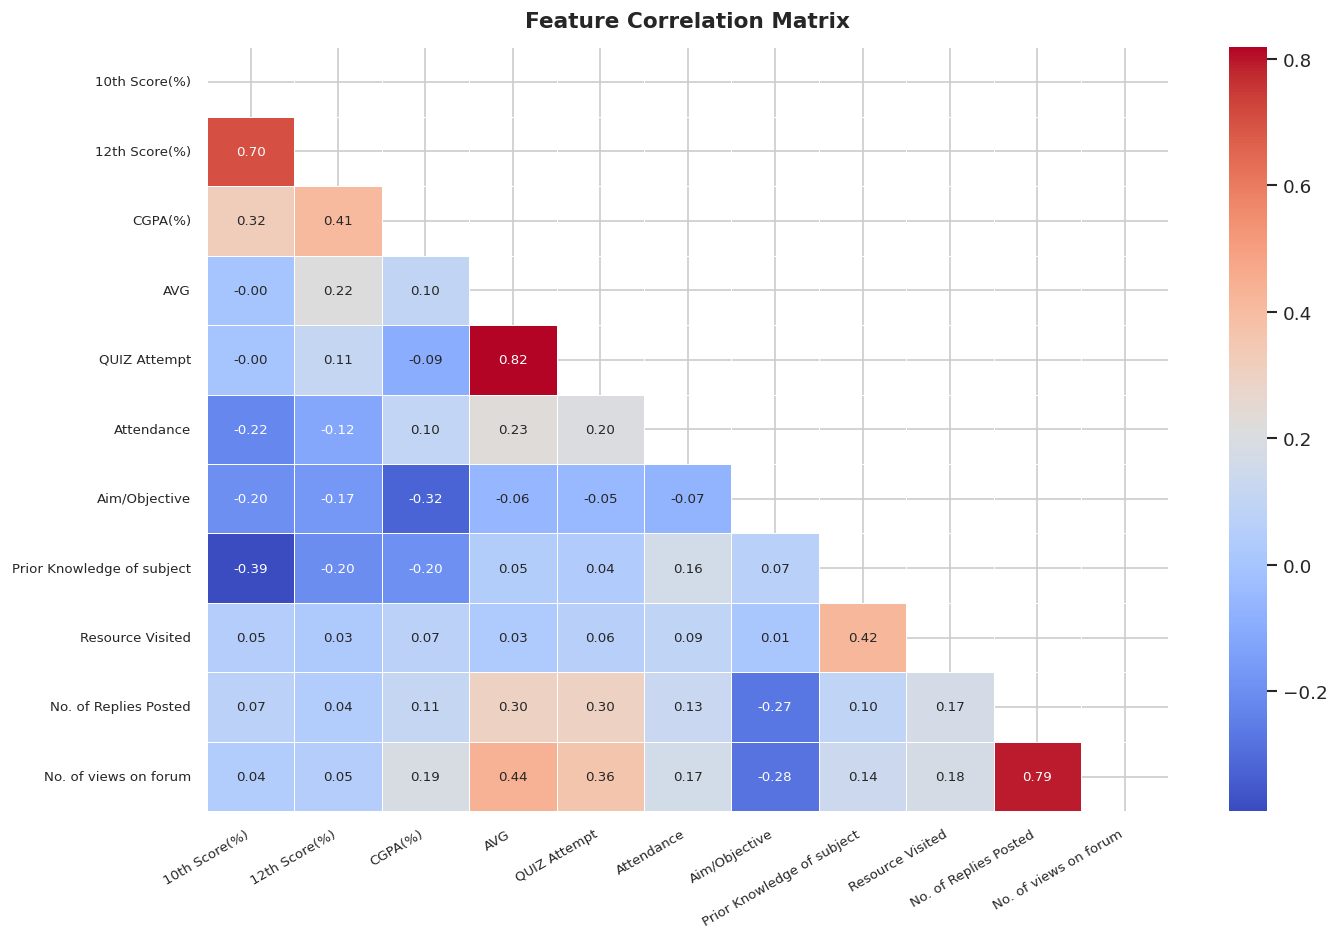

In [66]:
# ══ CELL 4: Preprocessing & Feature Engineering ══

FEATURE_COLS = [
    '10th Score(%)', '12th Score(%)', 'CGPA(%)', 'AVG',
    'QUIZ Attempt', 'Attendance', 'Aim/Objective',
    'Prior Knowledge of subject', 'Resource Visited',
    'No. of Replies Posted', 'No. of views on forum'
]

# ── Auto fix column names (works for BOTH datasets) ──
df_raw.columns = df_raw.columns.str.strip()
if 'Roll Number' in df_raw.columns:
    df_raw = df_raw.rename(columns={'Roll Number': 'Student ID'})
    print("✅ Renamed 'Roll Number' -> 'Student ID'")

# ── ID column ──
id_col = 'Student ID' if 'Student ID' in df_raw.columns else None
print(f"✅ ID column: {id_col}")

available_cols = [c for c in FEATURE_COLS if c in df_raw.columns]
print(f"✅ Features selected ({len(available_cols)}): {available_cols}")

df = df_raw.copy()

# ── Clip outliers ──
for col in available_cols:
    p99 = df[col].quantile(0.99)
    p01 = df[col].quantile(0.01)
    df[col] = df[col].clip(lower=p01, upper=p99)

# ── Impute missing ──
df[available_cols] = SimpleImputer(strategy='mean').fit_transform(df[available_cols])

# ── Scale ──
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(df[available_cols])

# ── PCA for 2D visualization ──
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

print(f"\n✅ PCA variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"   PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  |  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"✅ Scaled shape: {X_scaled.shape}")
print("✅ Preprocessing complete!")

# ── Correlation heatmap ──
fig, ax = plt.subplots(figsize=(12, 8))
corr = df[available_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, linecolor='white', ax=ax,
            annot_kws={'fontsize': 8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()


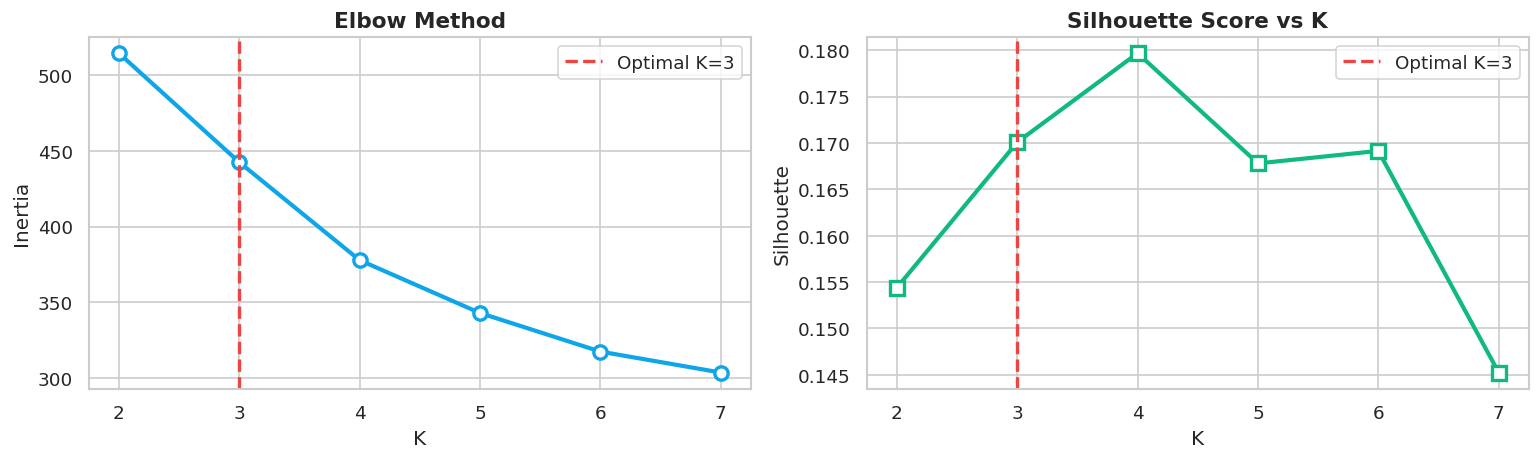

Best K: 4


In [67]:

# ══ CELL 5: Elbow + Silhouette ══
K_range, inertias, silhouettes = range(2,8), [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(list(K_range), inertias, 'o-', color='#0ea5e9', lw=2.5, ms=8,
             markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(x=3, color='#ef4444', ls='--', lw=2, label='Optimal K=3')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].legend()

axes[1].plot(list(K_range), silhouettes, 's-', color='#10b981', lw=2.5, ms=8,
             markerfacecolor='white', markeredgewidth=2)
axes[1].axvline(x=3, color='#ef4444', ls='--', lw=2, label='Optimal K=3')
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette'); axes[1].legend()

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best K: {list(K_range)[silhouettes.index(max(silhouettes))]}")


In [68]:

# ══ CELL 6: Cluster Naming Helper ══
def assign_cluster_names(df, label_col, name_col, feat_cols, n):
    df_n = df[feat_cols].copy()
    for col in feat_cols:
        r = df_n[col].max() - df_n[col].min()
        if r > 0: df_n[col] = (df_n[col] - df_n[col].min()) / r
    if 'Topic miss' in df_n.columns:
        df_n['Topic miss'] = 1 - df_n['Topic miss']
    scores = {lbl: df_n.loc[df[label_col]==lbl].mean().mean() for lbl in range(n)}
    sl = sorted(scores, key=scores.get, reverse=True)
    names = (['High-Performing','Moderate','At-Risk'] + [f'C{i}' for i in range(4,n+1)])[:n]
    df[name_col] = df[label_col].map({sl[i]: names[i] for i in range(n)})
    return df
print("Helper ready!")


Helper ready!


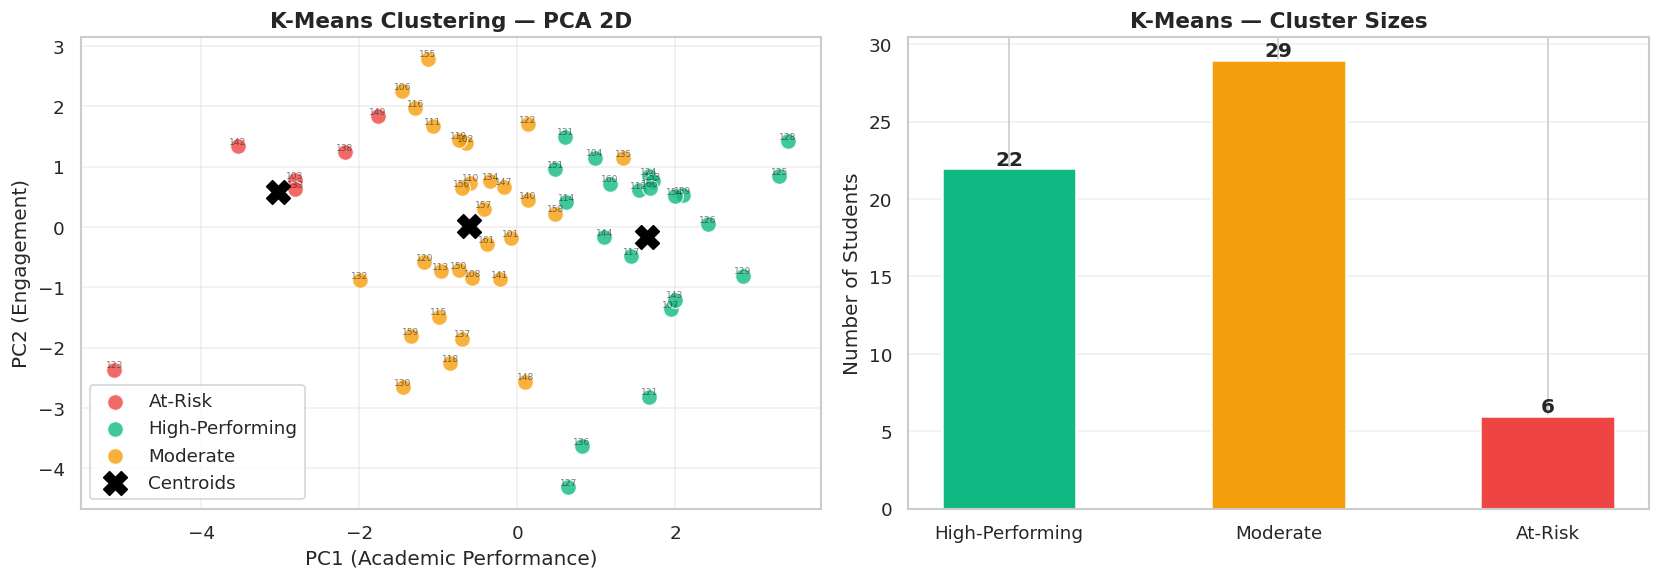

✅ K-Means Complete!
   Silhouette Score : 0.1701  (higher is better)
   Davies-Bouldin   : 1.7956  (lower  is better)

   Cluster Distribution:
kmeans_cluster
Moderate           29
High-Performing    22
At-Risk             6


In [69]:
# ══ CELL 7: K-Means Clustering ══

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df['kmeans_label'] = kmeans.fit_predict(X_scaled)
df = assign_cluster_names(df, 'kmeans_label', 'kmeans_cluster', available_cols, N_CLUSTERS)

sil_km = silhouette_score(X_scaled, df['kmeans_label'])
db_km  = davies_bouldin_score(X_scaled, df['kmeans_label'])

# ── auto detect ID column ──
id_col = 'Student ID' if 'Student ID' in df.columns else \
         'Roll Number' if 'Roll Number' in df.columns else None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
for name, grp in df.groupby('kmeans_cluster'):
    axes[0].scatter(grp['pca_x'], grp['pca_y'],
                    c=COLORS[name], label=name,
                    alpha=0.8, s=90, edgecolors='white', lw=0.8)

# Centroids
ctr_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(ctr_pca[:, 0], ctr_pca[:, 1],
                c='black', marker='X', s=200, zorder=6, label='Centroids')

# Annotate IDs if column exists
if id_col:
    for _, row in df.iterrows():
        axes[0].annotate(str(row[id_col]),
                         (row['pca_x'], row['pca_y']),
                         fontsize=5.5, alpha=0.6,
                         ha='center', va='bottom')

axes[0].set_title('K-Means Clustering — PCA 2D', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1 (Academic Performance)')
axes[0].set_ylabel('PC2 (Engagement)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cluster size bar chart
sizes = df['kmeans_cluster'].value_counts().reindex(
    ['High-Performing', 'Moderate', 'At-Risk']).dropna()
bars = axes[1].bar(sizes.index, sizes.values,
                   color=[COLORS[c] for c in sizes.index],
                   width=0.5, edgecolor='white', lw=1.5)
for bar, val in zip(bars, sizes.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 str(int(val)), ha='center',
                 fontweight='bold', fontsize=12)
axes[1].set_title('K-Means — Cluster Sizes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Students')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ K-Means Complete!")
print(f"   Silhouette Score : {sil_km:.4f}  (higher is better)")
print(f"   Davies-Bouldin   : {db_km:.4f}  (lower  is better)")
print(f"\n   Cluster Distribution:")
print(df['kmeans_cluster'].value_counts().to_string())


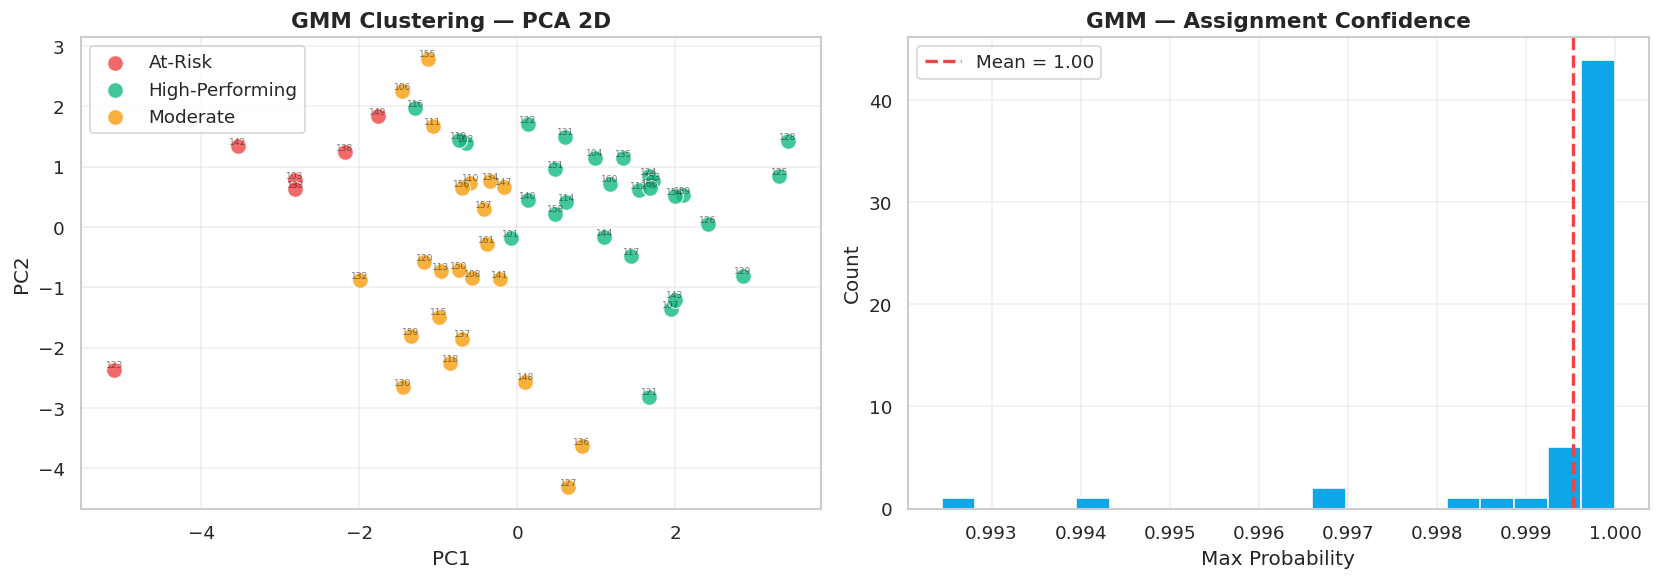

✅ GMM Complete!
   Silhouette Score : 0.1650
   Davies-Bouldin   : 1.8926
   BIC              : 1755.66  (lower = better)
   AIC              : 1279.63

   Cluster Distribution:
gmm_cluster
High-Performing    28
Moderate           23
At-Risk             6


In [70]:
# ══ CELL 8: GMM (Gaussian Mixture Model) Clustering ══

gmm = GaussianMixture(n_components=N_CLUSTERS, covariance_type='full',
                      random_state=42, n_init=5)
gmm.fit(X_scaled)
df['gmm_label'] = gmm.predict(X_scaled)
df['gmm_prob']  = gmm.predict_proba(X_scaled).max(axis=1)
df = assign_cluster_names(df, 'gmm_label', 'gmm_cluster', available_cols, N_CLUSTERS)

sil_gm = silhouette_score(X_scaled, df['gmm_label'])
db_gm  = davies_bouldin_score(X_scaled, df['gmm_label'])

# ── auto detect ID column ──
id_col = 'Student ID' if 'Student ID' in df.columns else \
         'Roll Number' if 'Roll Number' in df.columns else None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
for name, grp in df.groupby('gmm_cluster'):
    axes[0].scatter(grp['pca_x'], grp['pca_y'],
                    c=COLORS[name], label=name,
                    alpha=0.8, s=90, edgecolors='white', lw=0.8)

# Annotate IDs if column exists
if id_col:
    for _, row in df.iterrows():
        axes[0].annotate(str(row[id_col]),
                         (row['pca_x'], row['pca_y']),
                         fontsize=5.5, alpha=0.6,
                         ha='center', va='bottom')

axes[0].set_title('GMM Clustering — PCA 2D', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Confidence histogram
axes[1].hist(df['gmm_prob'], bins=20, color='#0ea5e9',
             edgecolor='white', lw=0.8)
axes[1].axvline(df['gmm_prob'].mean(), color='#ef4444', ls='--', lw=2,
                label=f"Mean = {df['gmm_prob'].mean():.2f}")
axes[1].set_title('GMM — Assignment Confidence', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Max Probability')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gmm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ GMM Complete!")
print(f"   Silhouette Score : {sil_gm:.4f}")
print(f"   Davies-Bouldin   : {db_gm:.4f}")
print(f"   BIC              : {gmm.bic(X_scaled):.2f}  (lower = better)")
print(f"   AIC              : {gmm.aic(X_scaled):.2f}")
print(f"\n   Cluster Distribution:")
print(df['gmm_cluster'].value_counts().to_string())


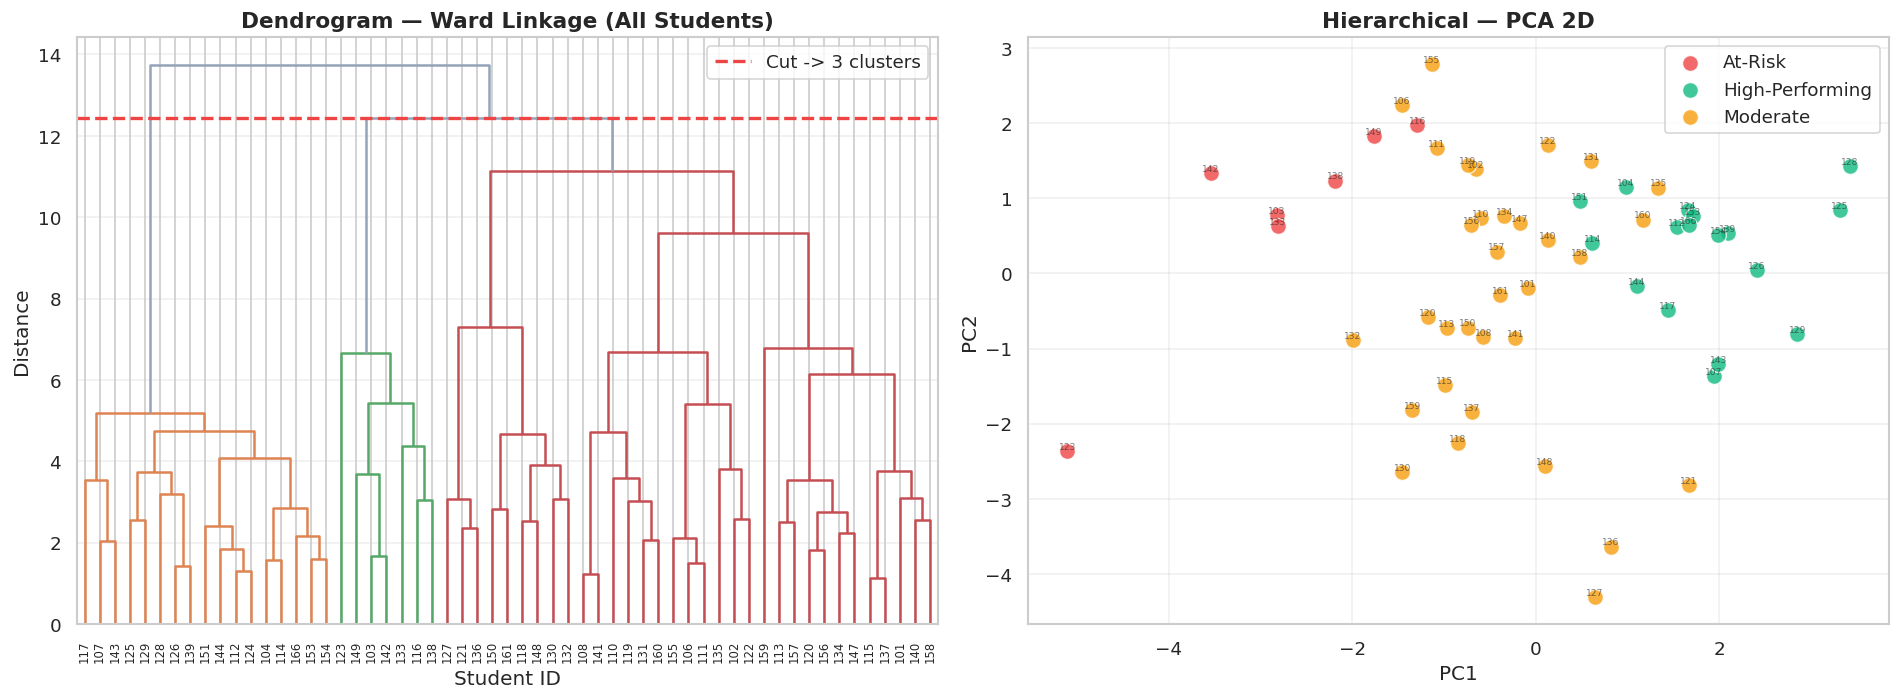

✅ Hierarchical Complete!
   Silhouette Score : 0.1425
   Davies-Bouldin   : 1.8062

   Cluster Distribution:
hier_cluster
Moderate           33
High-Performing    17
At-Risk             7


In [71]:
# ══ CELL 9: Hierarchical Clustering + Dendrogram ══

hc = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
df['hier_label'] = hc.fit_predict(X_scaled)
df = assign_cluster_names(df, 'hier_label', 'hier_cluster', available_cols, N_CLUSTERS)

sil_hc = silhouette_score(X_scaled, df['hier_label'])
db_hc  = davies_bouldin_score(X_scaled, df['hier_label'])

# ── auto detect ID column ──
id_col = 'Student ID' if 'Student ID' in df.columns else \
         'Roll Number' if 'Roll Number' in df.columns else None

# Use ID labels if available, else use index numbers
dendrogram_labels = df[id_col].astype(str).tolist() if id_col else None

Z = linkage(X_scaled, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogram
dendrogram(Z, ax=axes[0],
           labels=dendrogram_labels,
           color_threshold=Z[-N_CLUSTERS + 1, 2],
           above_threshold_color='#94a3b8',
           leaf_font_size=7, leaf_rotation=90)
axes[0].axhline(y=Z[-N_CLUSTERS + 1, 2],
                color='#ef4444', ls='--', lw=2,
                label=f'Cut -> {N_CLUSTERS} clusters')
axes[0].set_title('Dendrogram — Ward Linkage (All Students)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel(id_col if id_col else 'Index')
axes[0].set_ylabel('Distance')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# PCA Scatter
for name, grp in df.groupby('hier_cluster'):
    axes[1].scatter(grp['pca_x'], grp['pca_y'],
                    c=COLORS[name], label=name,
                    alpha=0.8, s=90, edgecolors='white', lw=0.8)

# Annotate IDs if column exists
if id_col:
    for _, row in df.iterrows():
        axes[1].annotate(str(row[id_col]),
                         (row['pca_x'], row['pca_y']),
                         fontsize=5.5, alpha=0.6,
                         ha='center', va='bottom')

axes[1].set_title('Hierarchical — PCA 2D', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Hierarchical Complete!")
print(f"   Silhouette Score : {sil_hc:.4f}")
print(f"   Davies-Bouldin   : {db_hc:.4f}")
print(f"\n   Cluster Distribution:")
print(df['hier_cluster'].value_counts().to_string())


,Algorithm,Silhouette Score(up),Davies-Bouldin(down),High-Performing,Moderate,At-Risk
0,K-Means,0.1701,1.7956,22,29,6
1,GMM,0.1650,1.8926,28,23,6
2,Hierarchical,0.1425,1.8062,17,33,7


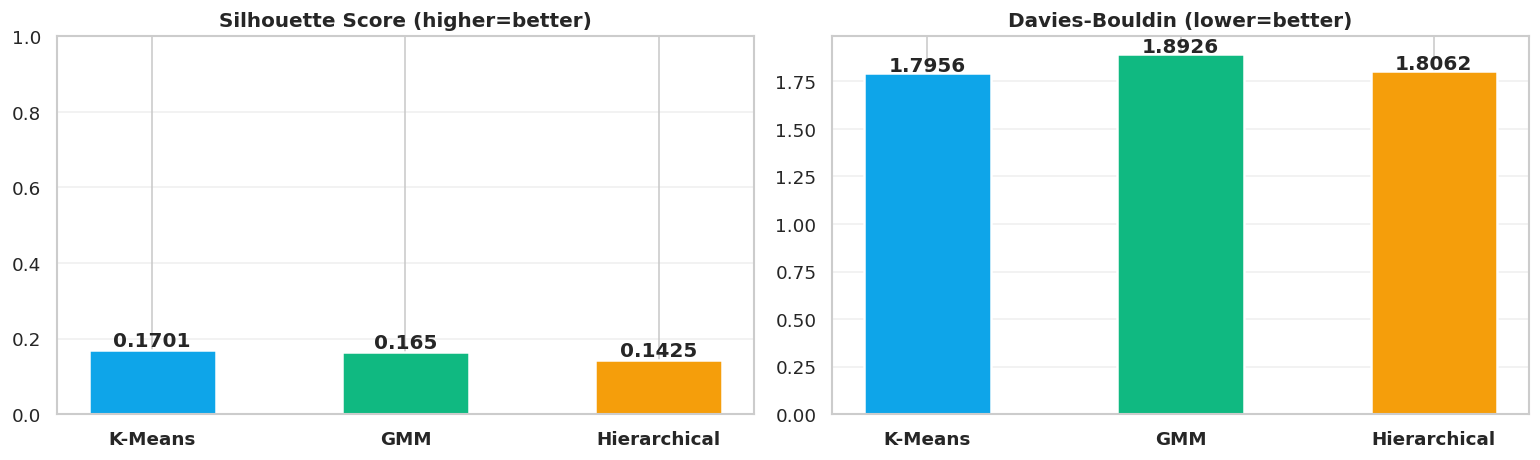

Best Algorithm: K-Means


In [72]:

# ══ CELL 10: Algorithm Comparison ══
df['final_cluster'] = df['kmeans_cluster']

comparison = pd.DataFrame({
    'Algorithm':           ['K-Means','GMM','Hierarchical'],
    'Silhouette Score(up)':[round(sil_km,4),round(sil_gm,4),round(sil_hc,4)],
    'Davies-Bouldin(down)' :[round(db_km,4), round(db_gm,4), round(db_hc,4)],
    'High-Performing':     [(df['kmeans_cluster']=='High-Performing').sum(),
                            (df['gmm_cluster']   =='High-Performing').sum(),
                            (df['hier_cluster']  =='High-Performing').sum()],
    'Moderate':            [(df['kmeans_cluster']=='Moderate').sum(),
                            (df['gmm_cluster']   =='Moderate').sum(),
                            (df['hier_cluster']  =='Moderate').sum()],
    'At-Risk':             [(df['kmeans_cluster']=='At-Risk').sum(),
                            (df['gmm_cluster']   =='At-Risk').sum(),
                            (df['hier_cluster']  =='At-Risk').sum()],
})
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
x, algos  = np.arange(3), comparison['Algorithm'].tolist()
bar_clrs  = ['#0ea5e9','#10b981','#f59e0b']

bars0 = axes[0].bar(x, comparison['Silhouette Score(up)'],
                    color=bar_clrs, width=0.5, edgecolor='white', lw=1.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(algos, fontweight='bold')
axes[0].set_title('Silhouette Score (higher=better)', fontsize=12, fontweight='bold')
axes[0].set_ylim(0,1); axes[0].grid(True, alpha=0.3, axis='y')
for bar,v in zip(bars0, comparison['Silhouette Score(up)']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 str(v), ha='center', fontweight='bold')

bars1 = axes[1].bar(x, comparison['Davies-Bouldin(down)'],
                    color=bar_clrs, width=0.5, edgecolor='white', lw=1.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(algos, fontweight='bold')
axes[1].set_title('Davies-Bouldin (lower=better)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for bar,v in zip(bars1, comparison['Davies-Bouldin(down)']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
best = comparison.loc[comparison['Silhouette Score(up)'].idxmax(),'Algorithm']
print(f"Best Algorithm: {best}")


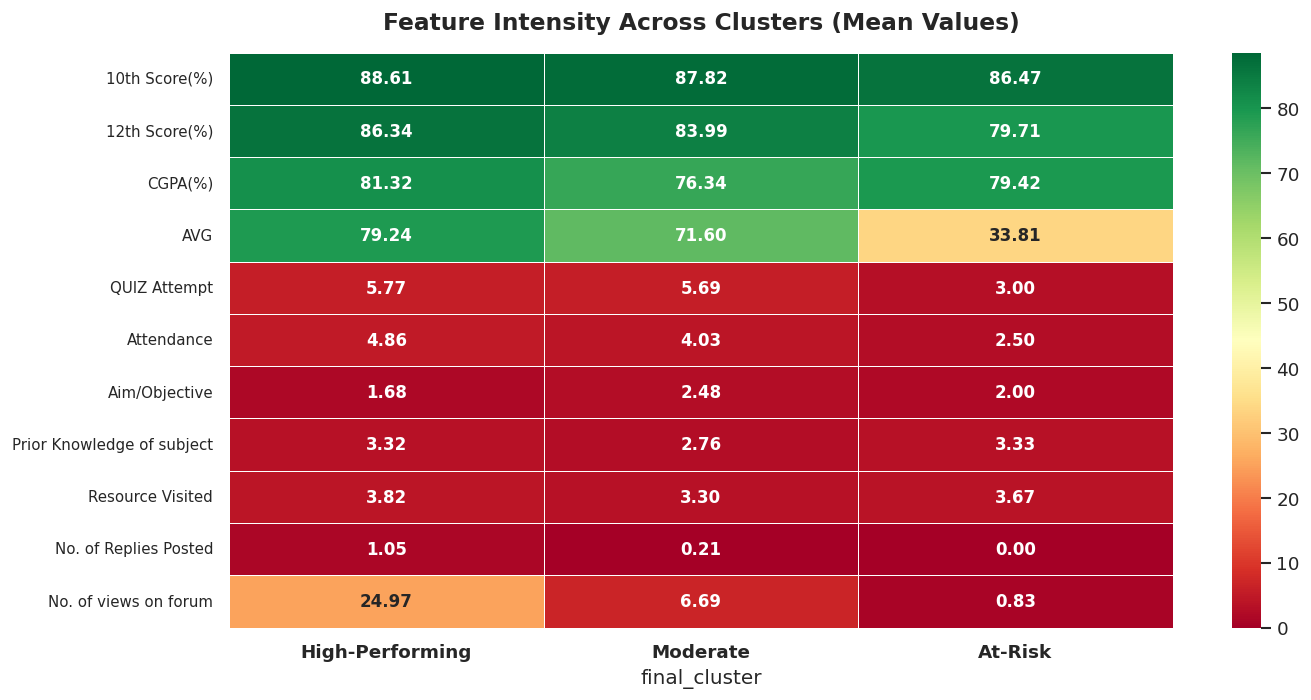

,10th Score(%),12th Score(%),CGPA(%),AVG,QUIZ Attempt,Attendance,Aim/Objective,Prior Knowledge of subject,Resource Visited,No. of Replies Posted,No. of views on forum
final_cluster,,,,,,,,,,,
High-Performing,88.61,86.34,81.32,79.24,5.77,4.86,1.68,3.32,3.82,1.05,24.97
Moderate,87.82,83.99,76.34,71.60,5.69,4.03,2.48,2.76,3.30,0.21,6.69
At-Risk,86.47,79.71,79.42,33.81,3.00,2.50,2.00,3.33,3.67,0.00,0.83


In [73]:

# ══ CELL 11: Feature Heatmap ══
hm_data = df.groupby('final_cluster')[available_cols].mean().round(2)
hm_data = hm_data.reindex([c for c in ['High-Performing','Moderate','At-Risk'] if c in hm_data.index])
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(hm_data.T, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={'fontsize':10,'fontweight':'bold'})
ax.set_title('Feature Intensity Across Clusters (Mean Values)',
             fontsize=14, fontweight='bold', pad=14)
plt.xticks(rotation=0, fontweight='bold')
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
display(hm_data)


In [74]:
 # ══ CELL 12: Export Results as CSV ══

df['dropout_risk'] = df['final_cluster'].map({
    'High-Performing': 'Low',
    'Moderate':        'Medium',
    'At-Risk':         'High'
})

# ── auto detect ID column ──
id_col = 'Student ID' if 'Student ID' in df.columns else \
         'Roll Number' if 'Roll Number' in df.columns else None

id_cols   = [id_col] if id_col else []
export_cols = id_cols + available_cols + \
              ['final_cluster', 'kmeans_cluster', 'gmm_cluster',
               'hier_cluster', 'dropout_risk', 'gmm_prob', 'pca_x', 'pca_y']
export_cols = [c for c in export_cols if c in df.columns]

df[export_cols].to_csv('cluster_results.csv', index=False)

from google.colab import files
files.download('cluster_results.csv')

print(f"✅ Exported {len(df)} students -> cluster_results.csv")
print("\nPreview:")
display(df[export_cols].head(10))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Exported 57 students -> cluster_results.csv

Preview:


,Student ID,10th Score(%),12th Score(%),CGPA(%),AVG,QUIZ Attempt,Attendance,Aim/Objective,Prior Knowledge of subject,Resource Visited,No. of Replies Posted,No. of views on forum,final_cluster,kmeans_cluster,gmm_cluster,hier_cluster,dropout_risk,gmm_prob,pca_x,pca_y
0,101,90.00,92.0,89.58,73.182222,5.0,6.0,3.0,5.0,5.00,0.0,6.0,Moderate,Moderate,High-Performing,Moderate,Medium,1.000000,-0.084198,-0.190107
1,102,87.00,91.0,87.56,71.036111,5.0,9.0,2.0,2.0,1.56,0.0,3.0,Moderate,Moderate,High-Performing,Moderate,Medium,0.998817,-0.651807,1.392799
2,103,93.00,85.0,81.22,38.888333,3.0,3.0,3.0,4.0,4.00,0.0,0.0,At-Risk,At-Risk,At-Risk,At-Risk,High,1.000000,-2.818536,0.777594
3,104,93.80,94.2,85.04,68.888889,5.0,5.0,2.0,3.0,4.00,1.0,16.0,High-Performing,High-Performing,High-Performing,High-Performing,Low,1.000000,0.984007,1.149928
4,106,96.20,92.4,79.50,70.442222,5.0,0.0,3.0,2.0,2.00,0.0,3.0,Moderate,Moderate,Moderate,Moderate,Medium,0.996951,-1.456369,2.245719
5,107,93.20,75.8,77.23,87.928889,6.0,7.0,2.0,4.0,4.00,1.0,30.0,High-Performing,High-Performing,High-Performing,High-Performing,Low,1.000000,1.938552,-1.366552
6,108,84.00,74.0,71.60,71.301111,6.0,5.0,1.0,3.0,3.00,0.0,8.0,Moderate,Moderate,Moderate,Moderate,Medium,0.999998,-0.572374,-0.851928
7,110,88.42,89.8,71.94,52.883333,6.0,0.0,2.0,3.0,2.00,1.0,8.0,Moderate,Moderate,Moderate,Moderate,Medium,0.999999,-0.597596,0.736417
8,111,94.30,89.8,80.42,68.081111,5.0,1.0,3.0,2.0,3.00,0.0,10.0,Moderate,Moderate,Moderate,Moderate,Medium,0.993959,-1.074673,1.671725
9,112,93.00,90.0,84.04,83.556667,6.0,4.0,2.0,3.0,4.00,1.0,15.0,High-Performing,High-Performing,High-Performing,High-Performing,Low,1.000000,1.534008,0.616205


In [84]:
# == CELL 13: Write Streamlit App ==
import json
app_code = json.loads("\"import streamlit as st\\nimport pandas as pd\\nimport numpy as np\\nimport plotly.express as px\\nimport plotly.graph_objects as go\\nfrom plotly.subplots import make_subplots\\nfrom sklearn.preprocessing import StandardScaler\\nfrom sklearn.cluster import KMeans, AgglomerativeClustering\\nfrom sklearn.mixture import GaussianMixture\\nfrom sklearn.decomposition import PCA\\nfrom sklearn.metrics import silhouette_score, davies_bouldin_score\\nfrom sklearn.impute import SimpleImputer\\nfrom scipy.cluster.hierarchy import dendrogram, linkage\\nimport matplotlib\\nmatplotlib.use(\\\"Agg\\\")\\nimport matplotlib.pyplot as plt\\nimport io, warnings\\nwarnings.filterwarnings(\\\"ignore\\\")\\n\\nst.set_page_config(\\n    page_title=\\\"Learning Analytics\\\",\\n    page_icon=\\\"\\ud83c\\udf93\\\",\\n    layout=\\\"wide\\\",\\n    initial_sidebar_state=\\\"expanded\\\"\\n)\\n\\nCLR = {\\n    \\\"High-Performing\\\": \\\"#10b981\\\",\\n    \\\"Moderate\\\":        \\\"#f59e0b\\\",\\n    \\\"At-Risk\\\":         \\\"#ef4444\\\"\\n}\\n\\nFEAT_COLS = [\\n    \\\"10th Score(%)\\\", \\\"12th Score(%)\\\", \\\"CGPA(%)\\\", \\\"AVG\\\",\\n    \\\"QUIZ Attempt\\\", \\\"Attendance\\\", \\\"Aim/Objective\\\",\\n    \\\"Prior Knowledge of subject\\\", \\\"Resource Visited\\\",\\n    \\\"No. of Replies Posted\\\", \\\"No. of views on forum\\\"\\n]\\n\\nQUIZ_COLS = [\\\"QUIZ 1\\\",\\\"QUIZ 2\\\",\\\"QUIZ 3\\\",\\\"QUIZ 4\\\",\\\"QUIZ 5\\\",\\\"QUIZ 6\\\"]\\n\\nst.markdown(\\\"\\\"\\\"\\n<style>\\n[data-testid=\\\"stAppViewContainer\\\"] { background: #0f172a; }\\n[data-testid=\\\"stSidebar\\\"] { background: #1e293b; }\\n[data-testid=\\\"stSidebar\\\"] * { color: #e2e8f0 !important; }\\n.main .block-container { padding-top: 1.2rem; }\\n\\n.top-bar {\\n    background: linear-gradient(135deg,#1e3a5f,#1e293b);\\n    border: 1px solid #334155; border-radius: 12px;\\n    padding: 1.2rem 2rem; margin-bottom: 1.2rem;\\n    display: flex; align-items: center; justify-content: space-between;\\n}\\n.top-title { font-size: 1.5rem; font-weight: 800; color: #f1f5f9; }\\n.top-sub   { font-size: .8rem; color: #64748b; margin-top: .2rem; }\\n\\n.kpi-row { display: flex; gap: .75rem; margin-bottom: 1.2rem; flex-wrap: wrap; }\\n.kpi {\\n    flex: 1; min-width: 130px; border-radius: 10px;\\n    padding: 1rem 1.2rem; text-align: center;\\n    border: 1px solid #334155;\\n}\\n.kpi.b { background: linear-gradient(135deg,#0c4a6e,#1e293b); }\\n.kpi.g { background: linear-gradient(135deg,#064e3b,#1e293b); }\\n.kpi.r { background: linear-gradient(135deg,#7f1d1d,#1e293b); }\\n.kpi.a { background: linear-gradient(135deg,#78350f,#1e293b); }\\n.kpi.p { background: linear-gradient(135deg,#4c1d95,#1e293b); }\\n.kv { font-size: 1.7rem; font-weight: 800; }\\n.kpi.b .kv { color: #38bdf8; }\\n.kpi.g .kv { color: #34d399; }\\n.kpi.r .kv { color: #f87171; }\\n.kpi.a .kv { color: #fbbf24; }\\n.kpi.p .kv { color: #a78bfa; }\\n.kl { font-size: .7rem; color: #64748b; text-transform: uppercase;\\n      letter-spacing: .04em; margin-top: .2rem; }\\n\\n.comp-tbl { width:100%; border-collapse:collapse; }\\n.comp-tbl th { background:#1e293b; color:#94a3b8; font-size:.75rem;\\n               padding:.7rem 1rem; border-bottom:2px solid #334155;\\n               text-align:left; text-transform:uppercase; }\\n.comp-tbl td { padding:.75rem 1rem; border-bottom:1px solid #1e293b;\\n               font-size:.85rem; color:#e2e8f0; }\\n.comp-tbl tr:hover td { background:#1e293b; }\\n.best { background:rgba(16,185,129,.2); color:#10b981;\\n        padding:.15rem .45rem; border-radius:4px;\\n        font-size:.7rem; font-weight:700; margin-left:.3rem; }\\n\\n.mbadge { display:flex; gap:.75rem; flex-wrap:wrap; margin-top:.75rem; }\\n.mb { background:#1e293b; border:1px solid #334155; border-radius:8px;\\n      padding:.65rem 1rem; text-align:center; flex:1; min-width:110px; }\\n.mbv { font-size:1.3rem; font-weight:800; }\\n.mbl { font-size:.68rem; color:#64748b; margin-top:.15rem; }\\n</style>\\n\\\"\\\"\\\", unsafe_allow_html=True)\\n\\n# \\u2500\\u2500 SIDEBAR \\u2500\\u2500\\nwith st.sidebar:\\n    st.markdown(\\\"### \\u2699\\ufe0f Settings\\\")\\n    uploaded     = st.file_uploader(\\\"Upload CSV\\\", type=[\\\"csv\\\"])\\n    st.divider()\\n    n_clusters   = st.slider(\\\"Clusters (K)\\\", 2, 6, 3)\\n    algorithm    = st.selectbox(\\\"Algorithm\\\", [\\\"K-Means\\\",\\\"GMM\\\",\\\"Hierarchical\\\"])\\n    st.divider()\\n    risk_filter  = st.multiselect(\\\"Risk Filter\\\",\\n                                  [\\\"High\\\",\\\"Medium\\\",\\\"Low\\\"],\\n                                  default=[\\\"High\\\",\\\"Medium\\\",\\\"Low\\\"])\\n    clust_filter = st.multiselect(\\\"Cluster Filter\\\",\\n                                  [\\\"High-Performing\\\",\\\"Moderate\\\",\\\"At-Risk\\\"],\\n                                  default=[\\\"High-Performing\\\",\\\"Moderate\\\",\\\"At-Risk\\\"])\\n\\n# \\u2500\\u2500 HELPERS \\u2500\\u2500\\ndef dl(fig, h=400):\\n    fig.update_layout(\\n        height=h, paper_bgcolor=\\\"#0f172a\\\", plot_bgcolor=\\\"#1e293b\\\",\\n        font=dict(color=\\\"#e2e8f0\\\", size=11),\\n        title_font=dict(color=\\\"#e2e8f0\\\", size=13),\\n        legend=dict(font=dict(color=\\\"#e2e8f0\\\"), bgcolor=\\\"rgba(0,0,0,0)\\\"),\\n        xaxis=dict(gridcolor=\\\"#334155\\\", tickfont=dict(color=\\\"#94a3b8\\\"),\\n                   title_font=dict(color=\\\"#94a3b8\\\")),\\n        yaxis=dict(gridcolor=\\\"#334155\\\", tickfont=dict(color=\\\"#94a3b8\\\"),\\n                   title_font=dict(color=\\\"#94a3b8\\\"))\\n    )\\n    return fig\\n\\ndef assign_names(df, lbl, name, feats, n):\\n    dn = df[feats].copy()\\n    for c in feats:\\n        r = dn[c].max()-dn[c].min()\\n        if r > 0: dn[c] = (dn[c]-dn[c].min())/r\\n    sc = {l: dn.loc[df[lbl]==l].mean().mean() for l in range(n)}\\n    sl = sorted(sc, key=sc.get, reverse=True)\\n    nm = ([\\\"High-Performing\\\",\\\"Moderate\\\",\\\"At-Risk\\\"]+\\n          [f\\\"C{i}\\\" for i in range(4,n+1)])[:n]\\n    df[name] = df[lbl].map({sl[i]:nm[i] for i in range(n)})\\n    return df\\n\\ndef grade(avg):\\n    if avg >= 75:   return \\\"O\\\"\\n    elif avg >= 60: return \\\"A\\\"\\n    elif avg >= 50: return \\\"B\\\"\\n    else:           return \\\"F\\\"\\n\\n# \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\nif uploaded:\\n    # \\u2500\\u2500 LOAD & PREPROCESS \\u2500\\u2500\\n    df_raw = pd.read_csv(uploaded)\\n    df_raw.columns = df_raw.columns.str.strip()\\n    if \\\"Roll Number\\\" in df_raw.columns:\\n        df_raw.rename(columns={\\\"Roll Number\\\":\\\"Student ID\\\"}, inplace=True)\\n\\n    FEAT  = [c for c in FEAT_COLS if c in df_raw.columns]\\n    QUIZZ = [c for c in QUIZ_COLS  if c in df_raw.columns]\\n    df    = df_raw.copy()\\n\\n    for col in FEAT:\\n        df[col] = df[col].clip(df[col].quantile(.01), df[col].quantile(.99))\\n    df[FEAT] = SimpleImputer(strategy=\\\"mean\\\").fit_transform(df[FEAT])\\n    X        = StandardScaler().fit_transform(df[FEAT])\\n    Xp       = PCA(n_components=2, random_state=42).fit_transform(X)\\n    df[\\\"px\\\"], df[\\\"py\\\"] = Xp[:,0], Xp[:,1]\\n\\n    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)\\n    df[\\\"km_lbl\\\"] = km.fit_predict(X)\\n    df = assign_names(df,\\\"km_lbl\\\",\\\"km_cls\\\",FEAT,n_clusters)\\n\\n    gm = GaussianMixture(n_components=n_clusters, random_state=42, n_init=5)\\n    gm.fit(X)\\n    df[\\\"gm_lbl\\\"]  = gm.predict(X)\\n    df[\\\"gm_prob\\\"] = gm.predict_proba(X).max(axis=1)\\n    df = assign_names(df,\\\"gm_lbl\\\",\\\"gm_cls\\\",FEAT,n_clusters)\\n\\n    hc = AgglomerativeClustering(n_clusters=n_clusters, linkage=\\\"ward\\\")\\n    df[\\\"hc_lbl\\\"] = hc.fit_predict(X)\\n    df = assign_names(df,\\\"hc_lbl\\\",\\\"hc_cls\\\",FEAT,n_clusters)\\n\\n    amap = {\\\"K-Means\\\":\\\"km_cls\\\",\\\"GMM\\\":\\\"gm_cls\\\",\\\"Hierarchical\\\":\\\"hc_cls\\\"}\\n    df[\\\"cluster\\\"]      = df[amap[algorithm]]\\n    df[\\\"dropout_risk\\\"] = df[\\\"cluster\\\"].map(\\n        {\\\"High-Performing\\\":\\\"Low\\\",\\\"Moderate\\\":\\\"Medium\\\",\\\"At-Risk\\\":\\\"High\\\"})\\n    df[\\\"Grade\\\"] = df[\\\"AVG\\\"].apply(grade)\\n\\n    sil = {\\\"K-Means\\\":     round(silhouette_score(X,df[\\\"km_lbl\\\"]),4),\\n           \\\"GMM\\\":         round(silhouette_score(X,df[\\\"gm_lbl\\\"]),4),\\n           \\\"Hierarchical\\\":round(silhouette_score(X,df[\\\"hc_lbl\\\"]),4)}\\n    dbs = {\\\"K-Means\\\":     round(davies_bouldin_score(X,df[\\\"km_lbl\\\"]),4),\\n           \\\"GMM\\\":         round(davies_bouldin_score(X,df[\\\"gm_lbl\\\"]),4),\\n           \\\"Hierarchical\\\":round(davies_bouldin_score(X,df[\\\"hc_lbl\\\"]),4)}\\n    best = max(sil, key=sil.get)\\n\\n    df_f = df[df[\\\"dropout_risk\\\"].isin(risk_filter) &\\n              df[\\\"cluster\\\"].isin(clust_filter)]\\n\\n    N   = len(df_f)\\n    hp  = (df_f[\\\"cluster\\\"]==\\\"High-Performing\\\").sum()\\n    mo  = (df_f[\\\"cluster\\\"]==\\\"Moderate\\\").sum()\\n    ar  = (df_f[\\\"cluster\\\"]==\\\"At-Risk\\\").sum()\\n    avg_perf = df_f[[\\\"CGPA(%)\\\",\\\"AVG\\\"]].mean().mean()\\n    pass_r   = (df_f[\\\"Grade\\\"]!=\\\"F\\\").sum()/max(N,1)*100\\n\\n    # \\u2500\\u2500 TOP BAR \\u2500\\u2500\\n    st.markdown(f\\\"\\\"\\\"\\n    <div class=\\\"top-bar\\\">\\n      <div>\\n        <div class=\\\"top-title\\\">\\ud83c\\udf93 Learning Analytics Dashboard</div>\\n        <div class=\\\"top-sub\\\">{N} students &nbsp;\\u00b7&nbsp; {algorithm} &nbsp;\\u00b7&nbsp; Best: {best}</div>\\n      </div>\\n    </div>\\n    \\\"\\\"\\\", unsafe_allow_html=True)\\n\\n    # \\u2500\\u2500 TABS \\u2500\\u2500\\n    t1,t2,t3,t4,t5,t6 = st.tabs([\\n        \\\"\\ud83c\\udfe0 Home\\\", \\\"\\ud83d\\udcca Overview\\\", \\\"\\ud83d\\udcc8 Learning Curve\\\",\\n        \\\"\\ud83c\\udfaf Performance\\\", \\\"\\ud83d\\udd2c Cluster Analysis\\\", \\\"\\ud83c\\udfc6 Course Outcomes\\\"\\n    ])\\n\\n    # \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550 HOME \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\n    with t1:\\n        st.markdown(f\\\"\\\"\\\"\\n        <div class=\\\"kpi-row\\\">\\n          <div class=\\\"kpi b\\\"><div class=\\\"kv\\\">{N}</div><div class=\\\"kl\\\">Total Students</div></div>\\n          <div class=\\\"kpi g\\\"><div class=\\\"kv\\\">{hp}</div><div class=\\\"kl\\\">High-Performing</div></div>\\n          <div class=\\\"kpi a\\\"><div class=\\\"kv\\\">{mo}</div><div class=\\\"kl\\\">Moderate</div></div>\\n          <div class=\\\"kpi r\\\"><div class=\\\"kv\\\">{ar}</div><div class=\\\"kl\\\">At-Risk</div></div>\\n          <div class=\\\"kpi p\\\"><div class=\\\"kv\\\">{avg_perf:.0f}%</div><div class=\\\"kl\\\">Avg Performance</div></div>\\n        </div>\\n        \\\"\\\"\\\", unsafe_allow_html=True)\\n\\n        c1, c2 = st.columns(2)\\n        with c1:\\n            sz = df_f[\\\"cluster\\\"].value_counts().reset_index()\\n            sz.columns = [\\\"Cluster\\\",\\\"Count\\\"]\\n            fig = px.pie(sz, names=\\\"Cluster\\\", values=\\\"Count\\\",\\n                         color=\\\"Cluster\\\", color_discrete_map=CLR,\\n                         hole=0.5, title=\\\"Cluster Distribution\\\")\\n            fig.update_traces(textfont_color=\\\"white\\\", textfont_size=13)\\n            st.plotly_chart(dl(fig, 350), use_container_width=True)\\n        with c2:\\n            st.markdown(f\\\"\\\"\\\"\\n            <div style=\\\"background:#1e293b;border:1px solid #334155;\\n                 border-radius:10px;padding:1.2rem 1.5rem;margin-top:.5rem;\\\">\\n              <p style=\\\"color:#38bdf8;font-weight:700;margin:0 0 .75rem;\\\">\\ud83d\\udccc Project Summary</p>\\n              <p style=\\\"color:#94a3b8;font-size:.85rem;line-height:1.7;margin:0\\\">\\n              Unsupervised ML on real M.Tech data (57 students).<br>\\n              Algorithms: K-Means \\u00b7 GMM \\u00b7 Hierarchical<br>\\n              Features: Academic scores, Attendance, Quiz, Forum activity<br><br>\\n              <strong style=\\\"color:#10b981\\\">Best Algorithm: {best}</strong><br>\\n              Silhouette = {sil[best]} &nbsp;|&nbsp; Davies-Bouldin = {dbs[best]}\\n              </p>\\n            </div>\\n            \\\"\\\"\\\", unsafe_allow_html=True)\\n\\n    # \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550 OVERVIEW \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\n    with t2:\\n        st.markdown(f\\\"\\\"\\\"\\n        <div class=\\\"kpi-row\\\">\\n          <div class=\\\"kpi b\\\"><div class=\\\"kv\\\">{avg_perf:.1f}%</div><div class=\\\"kl\\\">Avg CGPA+AVG</div></div>\\n          <div class=\\\"kpi r\\\"><div class=\\\"kv\\\">{ar/max(N,1)*100:.0f}%</div><div class=\\\"kl\\\">At-Risk</div></div>\\n          <div class=\\\"kpi a\\\"><div class=\\\"kv\\\">{df_f['Attendance'].mean():.1f}</div><div class=\\\"kl\\\">Avg Attendance</div></div>\\n          <div class=\\\"kpi g\\\"><div class=\\\"kv\\\">{pass_r:.0f}%</div><div class=\\\"kl\\\">Pass Rate</div></div>\\n        </div>\\n        \\\"\\\"\\\", unsafe_allow_html=True)\\n\\n        c1, c2 = st.columns(2)\\n        with c1:\\n            fig = px.bar(\\n                df_f[\\\"dropout_risk\\\"].value_counts().reset_index()\\n                    .rename(columns={\\\"dropout_risk\\\":\\\"Risk\\\",\\\"count\\\":\\\"Count\\\"}),\\n                x=\\\"Risk\\\", y=\\\"Count\\\", color=\\\"Risk\\\",\\n                color_discrete_map={\\\"High\\\":\\\"#ef4444\\\",\\\"Medium\\\":\\\"#f59e0b\\\",\\\"Low\\\":\\\"#10b981\\\"},\\n                text=\\\"Count\\\", title=\\\"Risk Distribution\\\")\\n            fig.update_traces(textposition=\\\"outside\\\",\\n                              marker_line_color=\\\"#0f172a\\\", marker_line_width=1.5)\\n            st.plotly_chart(dl(fig, 360), use_container_width=True)\\n        with c2:\\n            fig = px.box(df_f, x=\\\"cluster\\\", y=\\\"AVG\\\",\\n                         color=\\\"cluster\\\", color_discrete_map=CLR,\\n                         title=\\\"AVG Score by Cluster\\\", points=\\\"all\\\")\\n            fig.update_layout(showlegend=False)\\n            st.plotly_chart(dl(fig, 360), use_container_width=True)\\n\\n    # \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550 LEARNING CURVE \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\n    with t3:\\n        c1, c2 = st.columns([1,2])\\n        with c1:\\n            drop_r = 100 - pass_r\\n            fig = go.Figure(go.Pie(\\n                labels=[\\\"Pass\\\",\\\"Dropout\\\"],\\n                values=[pass_r, drop_r],\\n                hole=0.5,\\n                marker_colors=[\\\"#10b981\\\",\\\"#ef4444\\\"],\\n                textfont_size=13, textfont_color=\\\"white\\\"\\n            ))\\n            fig.update_layout(\\n                height=300, paper_bgcolor=\\\"#0f172a\\\",\\n                font=dict(color=\\\"#e2e8f0\\\"),\\n                legend=dict(font=dict(color=\\\"#e2e8f0\\\"),\\n                            bgcolor=\\\"rgba(0,0,0,0)\\\"),\\n                title=dict(text=\\\"Pass vs Dropout\\\", font=dict(color=\\\"#e2e8f0\\\")),\\n                margin=dict(t=40,b=10,l=10,r=10)\\n            )\\n            st.plotly_chart(fig, use_container_width=True)\\n            st.markdown(f\\\"\\\"\\\"\\n            <div style=\\\"color:#e2e8f0;font-size:.85rem;margin-top:.5rem;\\\">\\n              \\ud83d\\udfe2 Pass Rate &nbsp;<strong style=\\\"color:#34d399\\\">{pass_r:.1f}%</strong><br>\\n              \\ud83d\\udd34 Dropout Rate &nbsp;<strong style=\\\"color:#f87171\\\">{drop_r:.1f}%</strong>\\n            </div>\\n            \\\"\\\"\\\", unsafe_allow_html=True)\\n\\n        with c2:\\n            if QUIZZ:\\n                rows = []\\n                for cls in [\\\"High-Performing\\\",\\\"Moderate\\\",\\\"At-Risk\\\"]:\\n                    grp = df_f[df_f[\\\"cluster\\\"]==cls]\\n                    if not len(grp): continue\\n                    for q in QUIZZ:\\n                        rows.append({\\\"Cluster\\\":cls,\\\"Quiz\\\":q,\\n                                     \\\"Score\\\":grp[q].mean()})\\n                if rows:\\n                    fig = px.line(pd.DataFrame(rows),\\n                                  x=\\\"Quiz\\\", y=\\\"Score\\\",\\n                                  color=\\\"Cluster\\\",\\n                                  color_discrete_map=CLR,\\n                                  markers=True,\\n                                  title=\\\"Quiz Score Trend per Cluster\\\")\\n                    fig.update_traces(line_width=2.5, marker_size=8)\\n                    st.plotly_chart(dl(fig, 340), use_container_width=True)\\n            else:\\n                weeks = [\\\"W1\\\",\\\"W2\\\",\\\"W3\\\",\\\"W4\\\",\\\"W5\\\",\\\"W6\\\"]\\n                base  = df_f[\\\"AVG\\\"].mean()\\n                cur   = [base*f for f in [.55,.65,.72,.82,.90,1.0]]\\n                pred  = [base*f for f in [.50,.62,.75,.85,.93,1.05]]\\n                fig   = go.Figure()\\n                fig.add_trace(go.Scatter(x=weeks,y=cur,name=\\\"Current\\\",\\n                    mode=\\\"lines+markers\\\",\\n                    line=dict(color=\\\"#38bdf8\\\",width=2.5),\\n                    marker=dict(size=8)))\\n                fig.add_trace(go.Scatter(x=weeks,y=pred,name=\\\"Predicted\\\",\\n                    mode=\\\"lines+markers\\\",\\n                    line=dict(color=\\\"#94a3b8\\\",width=2,dash=\\\"dash\\\"),\\n                    marker=dict(size=8)))\\n                fig.update_layout(title=\\\"Performance Learning Curve\\\")\\n                st.plotly_chart(dl(fig, 340), use_container_width=True)\\n\\n    # \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550 PERFORMANCE \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\n    with t4:\\n        c1, c2 = st.columns(2)\\n        with c1:\\n            gc = df_f[\\\"Grade\\\"].value_counts().reset_index()\\n            gc.columns = [\\\"Grade\\\",\\\"Count\\\"]\\n            fig = go.Figure(go.Pie(\\n                labels=gc[\\\"Grade\\\"].tolist(),\\n                values=gc[\\\"Count\\\"].tolist(),\\n                hole=0.48,\\n                marker_colors=[\\\"#a78bfa\\\",\\\"#10b981\\\",\\\"#38bdf8\\\",\\\"#ef4444\\\"],\\n                textfont_size=14, textfont_color=\\\"white\\\",\\n                textinfo=\\\"label+percent\\\"\\n            ))\\n            fig.update_layout(\\n                height=360, paper_bgcolor=\\\"#0f172a\\\",\\n                font=dict(color=\\\"#e2e8f0\\\"),\\n                legend=dict(font=dict(color=\\\"#e2e8f0\\\"),\\n                            bgcolor=\\\"rgba(0,0,0,0)\\\"),\\n                title=dict(text=\\\"Grade Distribution (O/A/B/F)\\\",\\n                           font=dict(color=\\\"#e2e8f0\\\")),\\n                margin=dict(t=50,b=10,l=10,r=10)\\n            )\\n            st.plotly_chart(fig, use_container_width=True)\\n        with c2:\\n            gcls = (df_f.groupby([\\\"cluster\\\",\\\"Grade\\\"])\\n                        .size().reset_index(name=\\\"Count\\\"))\\n            fig  = px.bar(gcls, x=\\\"cluster\\\", y=\\\"Count\\\",\\n                          color=\\\"Grade\\\", barmode=\\\"group\\\",\\n                          title=\\\"Grades per Cluster\\\",\\n                          color_discrete_map={\\n                              \\\"O\\\":\\\"#a78bfa\\\",\\\"A\\\":\\\"#10b981\\\",\\n                              \\\"B\\\":\\\"#38bdf8\\\",\\\"F\\\":\\\"#ef4444\\\"})\\n            fig.update_traces(marker_line_color=\\\"#0f172a\\\",\\n                              marker_line_width=1.2)\\n            st.plotly_chart(dl(fig, 360), use_container_width=True)\\n\\n        # Box plots \\u2014 2 columns grid, key features only\\n        key_feats = [f for f in\\n                     [\\\"AVG\\\",\\\"CGPA(%)\\\",\\\"Attendance\\\",\\\"QUIZ Attempt\\\",\\n                      \\\"Resource Visited\\\",\\\"No. of views on forum\\\"]\\n                     if f in df_f.columns]\\n        fig_b = make_subplots(rows=2, cols=3,\\n                              subplot_titles=key_feats,\\n                              vertical_spacing=0.18,\\n                              horizontal_spacing=0.08)\\n        for fi, feat in enumerate(key_feats):\\n            r, c_ = fi//3+1, fi%3+1\\n            for cls, clr in CLR.items():\\n                grp = df_f[df_f[\\\"cluster\\\"]==cls][feat].dropna()\\n                fig_b.add_trace(\\n                    go.Box(y=grp.values, name=cls,\\n                           marker_color=clr, line_color=clr,\\n                           showlegend=(fi==0), boxmean=True),\\n                    row=r, col=c_)\\n        fig_b.update_layout(\\n            height=480, paper_bgcolor=\\\"#0f172a\\\",\\n            plot_bgcolor=\\\"#1e293b\\\",\\n            font=dict(color=\\\"#94a3b8\\\", size=10),\\n            legend=dict(font=dict(color=\\\"#e2e8f0\\\"),\\n                        bgcolor=\\\"rgba(0,0,0,0)\\\",\\n                        orientation=\\\"h\\\", y=1.05))\\n        for ann in fig_b.layout.annotations:\\n            ann.font.color = \\\"#e2e8f0\\\"\\n            ann.font.size  = 11\\n        for key in fig_b.layout:\\n            if key.startswith((\\\"xaxis\\\",\\\"yaxis\\\")):\\n                fig_b.layout[key].update(\\n                    gridcolor=\\\"#334155\\\",\\n                    tickfont=dict(color=\\\"#64748b\\\", size=9))\\n        st.plotly_chart(fig_b, use_container_width=True)\\n\\n    # \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550 CLUSTER ANALYSIS \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\n    with t5:\\n        ct1, ct2, ct3, ct4 = st.tabs(\\n            [\\\"K-Means\\\",\\\"GMM\\\",\\\"Hierarchical\\\",\\\"Comparison\\\"])\\n\\n        def scatter(df_in, ccol, title):\\n            hov = [c for c in [\\\"Student ID\\\",\\\"CGPA(%)\\\",\\\"AVG\\\",\\n                                \\\"Attendance\\\",\\\"dropout_risk\\\"]\\n                   if c in df_in.columns]\\n            fig = px.scatter(df_in, x=\\\"px\\\", y=\\\"py\\\", color=ccol,\\n                             color_discrete_map=CLR, opacity=0.85,\\n                             hover_data=hov, title=title,\\n                             labels={\\\"px\\\":\\\"PC1\\\",\\\"py\\\":\\\"PC2\\\"})\\n            if \\\"Student ID\\\" in df_in.columns:\\n                for _, row in df_in.iterrows():\\n                    fig.add_annotation(\\n                        x=row[\\\"px\\\"], y=row[\\\"py\\\"],\\n                        text=str(row[\\\"Student ID\\\"]),\\n                        showarrow=False,\\n                        font=dict(size=8, color=\\\"#e2e8f0\\\"),\\n                        yshift=10)\\n            fig.update_traces(marker=dict(size=11,\\n                              line=dict(width=1.5,color=\\\"#0f172a\\\")))\\n            return dl(fig, 440)\\n\\n        def mbadge(s_val, db_val, hp_n, ar_n, s_clr, db_clr):\\n            st.markdown(f\\\"\\\"\\\"\\n            <div class=\\\"mbadge\\\">\\n              <div class=\\\"mb\\\"><div class=\\\"mbv\\\" style=\\\"color:{s_clr}\\\">{s_val}</div>\\n                <div class=\\\"mbl\\\">Silhouette \\u2191</div></div>\\n              <div class=\\\"mb\\\"><div class=\\\"mbv\\\" style=\\\"color:{db_clr}\\\">{db_val}</div>\\n                <div class=\\\"mbl\\\">Davies-Bouldin \\u2193</div></div>\\n              <div class=\\\"mb\\\"><div class=\\\"mbv\\\" style=\\\"color:#34d399\\\">{hp_n}</div>\\n                <div class=\\\"mbl\\\">High-Performing</div></div>\\n              <div class=\\\"mb\\\"><div class=\\\"mbv\\\" style=\\\"color:#f87171\\\">{ar_n}</div>\\n                <div class=\\\"mbl\\\">At-Risk</div></div>\\n            </div>\\n            \\\"\\\"\\\", unsafe_allow_html=True)\\n\\n        with ct1:\\n            a,b = st.columns([2,1])\\n            with a: st.plotly_chart(scatter(df_f,\\\"km_cls\\\",\\\"K-Means\\\"),\\n                                    use_container_width=True)\\n            with b:\\n                sz = df_f[\\\"km_cls\\\"].value_counts().reset_index()\\n                sz.columns=[\\\"Cluster\\\",\\\"Count\\\"]\\n                fig=px.pie(sz,names=\\\"Cluster\\\",values=\\\"Count\\\",\\n                           color=\\\"Cluster\\\",color_discrete_map=CLR,\\n                           hole=0.48)\\n                fig.update_traces(textfont_color=\\\"white\\\",textfont_size=12)\\n                st.plotly_chart(dl(fig,440),use_container_width=True)\\n            mbadge(sil[\\\"K-Means\\\"], dbs[\\\"K-Means\\\"],\\n                   (df_f[\\\"km_cls\\\"]==\\\"High-Performing\\\").sum(),\\n                   (df_f[\\\"km_cls\\\"]==\\\"At-Risk\\\").sum(),\\n                   \\\"#38bdf8\\\",\\\"#f87171\\\")\\n\\n        with ct2:\\n            a,b = st.columns([2,1])\\n            with a: st.plotly_chart(scatter(df_f,\\\"gm_cls\\\",\\\"GMM\\\"),\\n                                    use_container_width=True)\\n            with b:\\n                fig = px.histogram(df_f,x=\\\"gm_prob\\\",color=\\\"gm_cls\\\",\\n                                   color_discrete_map=CLR,nbins=20,\\n                                   title=\\\"Confidence\\\",barmode=\\\"overlay\\\",\\n                                   opacity=0.75)\\n                st.plotly_chart(dl(fig,440),use_container_width=True)\\n            mbadge(sil[\\\"GMM\\\"],dbs[\\\"GMM\\\"],\\n                   (df_f[\\\"gm_cls\\\"]==\\\"High-Performing\\\").sum(),\\n                   (df_f[\\\"gm_cls\\\"]==\\\"At-Risk\\\").sum(),\\n                   \\\"#38bdf8\\\",\\\"#f87171\\\")\\n\\n        with ct3:\\n            a,b = st.columns([3,2])\\n            with a: st.plotly_chart(scatter(df_f,\\\"hc_cls\\\",\\\"Hierarchical\\\"),\\n                                    use_container_width=True)\\n            with b:\\n                st.markdown('<p style=\\\"color:#e2e8f0;font-weight:700;'\\n                            'margin-bottom:.4rem;\\\">Dendrogram</p>',\\n                            unsafe_allow_html=True)\\n                Z2     = linkage(X, method=\\\"ward\\\")\\n                fd, ax = plt.subplots(figsize=(5,4))\\n                fd.patch.set_facecolor(\\\"#1e293b\\\")\\n                ax.set_facecolor(\\\"#1e293b\\\")\\n                lbls = (df[\\\"Student ID\\\"].astype(str).tolist()\\n                        if \\\"Student ID\\\" in df.columns else None)\\n                dendrogram(Z2, ax=ax, labels=lbls,\\n                           color_threshold=Z2[-n_clusters+1,2],\\n                           above_threshold_color=\\\"#475569\\\",\\n                           leaf_font_size=6, leaf_rotation=90)\\n                ax.axhline(y=Z2[-n_clusters+1,2],\\n                           color=\\\"#ef4444\\\", ls=\\\"--\\\", lw=1.8)\\n                ax.set_title(\\\"Ward Linkage\\\", color=\\\"#e2e8f0\\\",\\n                             fontsize=10, fontweight=\\\"bold\\\")\\n                ax.tick_params(colors=\\\"#64748b\\\")\\n                for sp in ax.spines.values():\\n                    sp.set_edgecolor(\\\"#334155\\\")\\n                plt.tight_layout()\\n                buf = io.BytesIO()\\n                fd.savefig(buf,format=\\\"png\\\",dpi=110,bbox_inches=\\\"tight\\\")\\n                buf.seek(0)\\n                b.image(buf,use_container_width=True)\\n                plt.close(fd)\\n            mbadge(sil[\\\"Hierarchical\\\"],dbs[\\\"Hierarchical\\\"],\\n                   (df_f[\\\"hc_cls\\\"]==\\\"High-Performing\\\").sum(),\\n                   (df_f[\\\"hc_cls\\\"]==\\\"At-Risk\\\").sum(),\\n                   \\\"#38bdf8\\\",\\\"#f87171\\\")\\n\\n        with ct4:\\n            best_s = max(sil,key=sil.get)\\n            best_d = min(dbs,key=dbs.get)\\n            rows   = \\\"\\\"\\n            for al in [\\\"K-Means\\\",\\\"GMM\\\",\\\"Hierarchical\\\"]:\\n                ck = {\\\"K-Means\\\":\\\"km_cls\\\",\\\"GMM\\\":\\\"gm_cls\\\",\\n                      \\\"Hierarchical\\\":\\\"hc_cls\\\"}[al]\\n                hp_= (df[ck]==\\\"High-Performing\\\").sum()\\n                mo_= (df[ck]==\\\"Moderate\\\").sum()\\n                ar_= (df[ck]==\\\"At-Risk\\\").sum()\\n                sb = '<span class=\\\"best\\\">BEST</span>' if al==best_s else \\\"\\\"\\n                db_ = '<span class=\\\"best\\\">BEST</span>' if al==best_d else \\\"\\\"\\n                rows += f\\\"\\\"\\\"<tr>\\n                  <td><strong style=\\\"color:#e2e8f0\\\">{al}</strong></td>\\n                  <td>{sil[al]}{sb}</td><td>{dbs[al]}{db_}</td>\\n                  <td><span style=\\\"color:#10b981;font-weight:700\\\">{hp_}</span></td>\\n                  <td><span style=\\\"color:#f59e0b;font-weight:700\\\">{mo_}</span></td>\\n                  <td><span style=\\\"color:#ef4444;font-weight:700\\\">{ar_}</span></td>\\n                </tr>\\\"\\\"\\\"\\n            st.markdown(f\\\"\\\"\\\"\\n            <table class=\\\"comp-tbl\\\">\\n              <thead><tr>\\n                <th>Algorithm</th><th>Silhouette \\u2191</th>\\n                <th>Davies-Bouldin \\u2193</th>\\n                <th style=\\\"color:#10b981\\\">High</th>\\n                <th style=\\\"color:#f59e0b\\\">Moderate</th>\\n                <th style=\\\"color:#ef4444\\\">At-Risk</th>\\n              </tr></thead>\\n              <tbody>{rows}</tbody>\\n            </table><br>\\n            \\\"\\\"\\\", unsafe_allow_html=True)\\n\\n            fc = make_subplots(1,2,\\n                    subplot_titles=[\\\"Silhouette\\\",\\\"Davies-Bouldin\\\"])\\n            bc = [\\\"#0ea5e9\\\",\\\"#10b981\\\",\\\"#f59e0b\\\"]\\n            fc.add_trace(go.Bar(x=list(sil.keys()),y=list(sil.values()),\\n                                marker_color=bc,text=list(sil.values()),\\n                                textposition=\\\"outside\\\"),row=1,col=1)\\n            fc.add_trace(go.Bar(x=list(dbs.keys()),y=list(dbs.values()),\\n                                marker_color=bc,text=list(dbs.values()),\\n                                textposition=\\\"outside\\\"),row=1,col=2)\\n            fc.update_layout(height=360,showlegend=False,\\n                             paper_bgcolor=\\\"#0f172a\\\",plot_bgcolor=\\\"#1e293b\\\",\\n                             font=dict(color=\\\"#e2e8f0\\\"))\\n            fc.update_annotations(font_color=\\\"#e2e8f0\\\")\\n            for k in fc.layout:\\n                if k.startswith((\\\"xaxis\\\",\\\"yaxis\\\")):\\n                    fc.layout[k].update(gridcolor=\\\"#334155\\\",\\n                                        tickfont=dict(color=\\\"#94a3b8\\\"))\\n            st.plotly_chart(fc, use_container_width=True)\\n\\n    # \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550 COURSE OUTCOMES \\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\u2550\\n    with t6:\\n        co = pd.DataFrame({\\n            \\\"CO\\\":[\\\"CO1: Academic\\\",\\\"CO2: Attendance\\\",\\n                  \\\"CO3: Prior Knowledge\\\",\\\"CO4: Engagement\\\",\\\"CO5: CGPA\\\"],\\n            \\\"Attainment\\\":[\\n                df_f[\\\"AVG\\\"].mean(),\\n                df_f[\\\"Attendance\\\"].mean()*10,\\n                df_f[\\\"Prior Knowledge of subject\\\"].mean()*20\\n                if \\\"Prior Knowledge of subject\\\" in df_f.columns else 0,\\n                ((df_f.get(\\\"Resource Visited\\\",pd.Series([0])).mean() +\\n                  df_f.get(\\\"No. of Replies Posted\\\",pd.Series([0])).mean())/2)*20,\\n                df_f[\\\"CGPA(%)\\\"].mean()\\n            ]\\n        })\\n        co[\\\"Attainment\\\"] = co[\\\"Attainment\\\"].clip(0,100).round(1)\\n\\n        cols_co = st.columns(5)\\n        co_clrs = [\\\"#38bdf8\\\",\\\"#10b981\\\",\\\"#f59e0b\\\",\\\"#a78bfa\\\",\\\"#f472b6\\\"]\\n        for i,(_,row) in enumerate(co.iterrows()):\\n            with cols_co[i]:\\n                st.markdown(f\\\"\\\"\\\"\\n                <div style=\\\"background:#1e293b;border:1px solid #334155;\\n                     border-radius:10px;padding:1rem;text-align:center;\\\">\\n                  <div style=\\\"font-size:1.6rem;font-weight:800;\\n                       color:{co_clrs[i]}\\\">{row['Attainment']}%</div>\\n                  <div style=\\\"font-size:.68rem;color:#64748b;\\n                       margin-top:.2rem\\\">{row['CO']}</div>\\n                </div>\\n                \\\"\\\"\\\", unsafe_allow_html=True)\\n\\n        st.markdown(\\\"<br>\\\", unsafe_allow_html=True)\\n        fig_co = px.bar(co, x=\\\"CO\\\", y=\\\"Attainment\\\",\\n                        text=\\\"Attainment\\\",\\n                        title=\\\"Course Outcome Attainment (%)\\\",\\n                        color=\\\"Attainment\\\",\\n                        color_continuous_scale=\\\"RdYlGn\\\",\\n                        range_color=[0,100])\\n        fig_co.update_traces(texttemplate=\\\"%{text}%\\\",\\n                             textposition=\\\"outside\\\",\\n                             marker_line_color=\\\"#0f172a\\\",\\n                             marker_line_width=1.5)\\n        fig_co.update_layout(yaxis=dict(range=[0,115]))\\n        st.plotly_chart(dl(fig_co, 380), use_container_width=True)\\n\\n        bco = co.loc[co[\\\"Attainment\\\"].idxmax()]\\n        wco = co.loc[co[\\\"Attainment\\\"].idxmin()]\\n        c1, c2 = st.columns(2)\\n        c1.success(f\\\"Best: {bco['CO']} ({bco['Attainment']}%)\\\")\\n        c2.error(f\\\"Needs Work: {wco['CO']} ({wco['Attainment']}%)\\\")\\n\\n    # \\u2500\\u2500 DOWNLOAD \\u2500\\u2500\\n    st.divider()\\n    ec = [c for c in\\n          ([\\\"Student ID\\\"] if \\\"Student ID\\\" in df.columns else []) +\\n          FEAT + [\\\"Grade\\\",\\\"cluster\\\",\\\"km_cls\\\",\\\"gm_cls\\\",\\\"hc_cls\\\",\\\"dropout_risk\\\"]\\n          if c in df.columns]\\n    st.download_button(\\\"\\u2b07\\ufe0f Download Results CSV\\\",\\n                       df[ec].to_csv(index=False),\\n                       \\\"results.csv\\\",\\\"text/csv\\\")\\n\\nelse:\\n    st.markdown(\\\"\\\"\\\"\\n    <div style=\\\"background:#1e293b;border:2px dashed #334155;border-radius:14px;\\n                padding:3rem;text-align:center;margin-top:3rem;\\\">\\n      <div style=\\\"font-size:3rem;\\\">\\ud83d\\udcc2</div>\\n      <h3 style=\\\"color:#e2e8f0;margin:.5rem 0;\\\">Upload CSV from sidebar</h3>\\n      <p style=\\\"color:#64748b;margin:0;\\\">\\n        Supports both Mtech_Selected_ML_Ready.csv and Mtechlabeldataset.csv\\n      </p>\\n    </div>\\n    \\\"\\\"\\\", unsafe_allow_html=True)\\n\"")
with open('app.py', 'w', encoding='utf-8', errors='replace') as f:
    f.write(app_code)
print('app.py written!', len(app_code), 'chars')


app.py written! 29297 chars


In [85]:
with open("app.py", "r") as f:
    print(f.read()[:1000])

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import io, warnings
warnings.filterwarnings("ignore")

st.set_page_config(
    page_title="Learning Analytics",
    page_icon="🎓",
    layout="wide",
    initial_sidebar_state="expanded"
)

CLR = {
    "High-Performing": "#10b981",
    "Moderate":        "#f59e0b",
    "At-Risk":         "#ef4444"
}

FEAT_COLS = [
    "10th Score(%)", "12th Score(%)", "CGPA(%)", "AVG",
    "QUIZ Attempt", "Attendance", "

In [86]:
from google.colab import files

files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
!pip install pyngrok -q

In [89]:

# ══ CELL 14: Launch Streamlit via pyngrok ══
# Get FREE token at https://ngrok.com/signup
from pyngrok import ngrok, conf
import subprocess, time, os
NGROK_TOKEN = "3AZq2JpR0rPY9ogQDpH7j4CGgP7_Ycjr7ETGzJmDbpfK3kXo"   # <-- paste token here
conf.get_default().auth_token = NGROK_TOKEN

os.system("pkill -f streamlit 2>/dev/null")
time.sleep(1)

proc = subprocess.Popen(
    ["streamlit","run","app.py",
     "--server.port=8501",
     "--server.headless=true",
     "--server.enableCORS=false",
     "--server.enableXsrfProtection=false"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(5)
url = ngrok.connect(8501)
print("=" * 60)
print("Streamlit Dashboard is LIVE!")
print(f"Open this URL: {url}")
print("=" * 60)
print("Upload Mtech_Selected_ML_Ready.csv inside the dashboard")
print("Keep this cell running to stay connected!")


Streamlit Dashboard is LIVE!
Open this URL: NgrokTunnel: "https://wesley-diphyllous-directly.ngrok-free.dev" -> "http://localhost:8501"
Upload Mtech_Selected_ML_Ready.csv inside the dashboard
Keep this cell running to stay connected!


In [81]:

# ══ CELL 15: Stop Server (run when done) ══
from pyngrok import ngrok
import os
ngrok.kill()
os.system("pkill -f streamlit")
print("Stopped!")


Stopped!


In [ ]:
print(df.columns.tolist())

['Student ID', 'Gender', '10th Score(%)', '12th Score(%)', 'CGPA(%)', 'QUIZ 1', 'QUIZ 2', 'QUIZ 3', 'QUIZ 4', 'QUIZ 5', 'QUIZ 6', 'AVG', 'QUIZ Attempt', 'Attendance', 'Aim/Objective', 'Prior Knowledge of subject', 'Resource Visited', 'No. of Replies Posted', 'No. of views on forum', 'Class', 'pca_x', 'pca_y', 'kmeans_label', 'kmeans_cluster', 'gmm_label', 'gmm_prob', 'gmm_cluster', 'hier_label', 'hier_cluster', 'final_cluster', 'dropout_risk']
